In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
# 배경에 눈금선 추가
sns.set_style("whitegrid")

# 0. 가상의 TV 광고비와 판매량 데이터 생성 (데이터 50개)

In [4]:
np.random.seed(42)
# TV 광고비: 10 ~ 300 사이의 임의의 숫자 50개
X_tv = np.random.uniform(10, 300, 50) 

# 판매량: 기본 판매량 5 + (광고비 * 0.05) + 예측 불가능한 오차(노이즈)
noise = np.random.normal(0, 2.5, 50)
y_sales = 5 + (0.05 * X_tv) + noise

df = pd.DataFrame({'TV_Ads': X_tv, 'Sales': y_sales})

# [시각화 1단계] 순수 데이터 확인 (산점도)

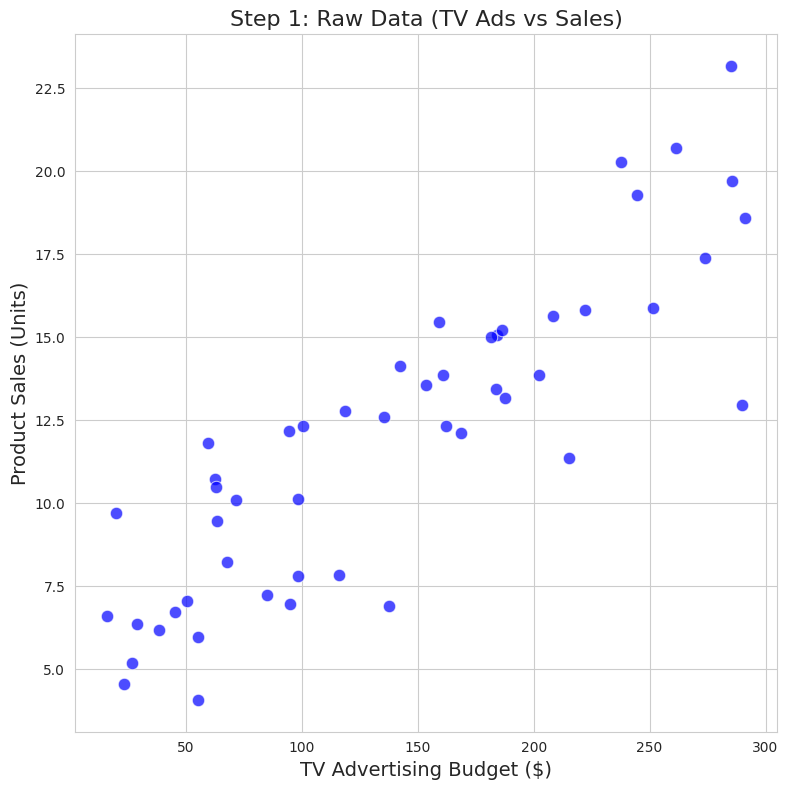

In [5]:
plt.figure(figsize=(8, 8))

sns.scatterplot(x='TV_Ads', y='Sales', data=df, color='blue', s=80, alpha=0.7)

plt.title('Step 1: Raw Data (TV Ads vs Sales)', fontsize=16)
plt.xlabel('TV Advertising Budget ($)', fontsize=14)
plt.ylabel('Product Sales (Units)', fontsize=14)

# 첫 번째 그래프 출력 완료
plt.tight_layout()
plt.show()

# [시각화 2단계] 최소제곱법 적용 및 잔차(Residual) 시각화

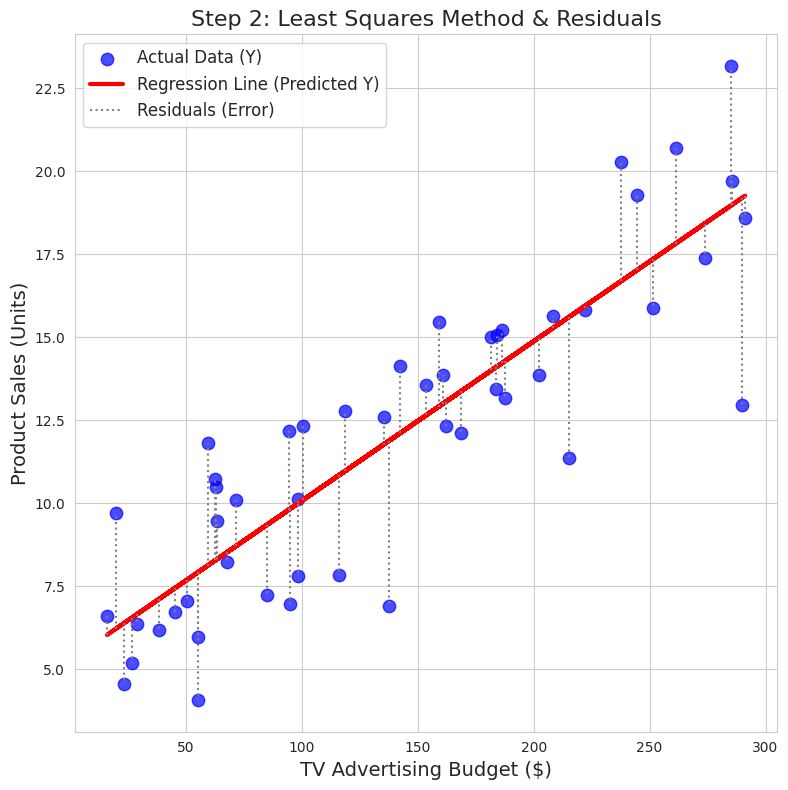

In [6]:
# 1. 사이킷런(sklearn)을 이용해 단순선형회귀 모델 학습
model = LinearRegression()
# X 데이터는 2차원 배열 형태여야 하므로 reshape 적용
X_train = df[['TV_Ads']] 
y_train = df['Sales']
model.fit(X_train, y_train)

# 2. 학습된 모델이 예측한 직선의 Y값들 계산
y_pred = model.predict(X_train)

# 다시 큼직한 도화지 준비
plt.figure(figsize=(8, 8))

# 원본 데이터 산점도 (파란 점)
plt.scatter(df['TV_Ads'], df['Sales'], color='blue', s=80, alpha=0.7, label='Actual Data (Y)')

# 최소제곱법으로 찾은 최적의 직선 (빨간 실선)
plt.plot(df['TV_Ads'], y_pred, color='red', linewidth=3, label='Regression Line (Predicted Y)')

# ★ 핵심: 잔차(Residual) 시각화 (실제 점과 직선 사이의 거리)
# 각 점마다 실제값과 직선 사이를 이어주는 점선을 그립니다.
for i in range(len(df)):
    plt.vlines(df['TV_Ads'][i], y_pred[i], df['Sales'][i], color='gray', linestyle='dotted', linewidth=1.5)

# 범례에 잔차 선 설명 추가를 위한 가짜(dummy) 선분
plt.plot([], [], color='gray', linestyle='dotted', linewidth=1.5, label='Residuals (Error)')

plt.title('Step 2: Least Squares Method & Residuals', fontsize=16)
plt.xlabel('TV Advertising Budget ($)', fontsize=14)
plt.ylabel('Product Sales (Units)', fontsize=14)
plt.legend(loc='upper left', fontsize=12)

# 두 번째 그래프 출력 완료
plt.tight_layout()
plt.show()

# 3. 모델 학습 결과(회귀 계수) 텍스트 출력

In [7]:
print("=== 단순선형회귀 학습 결과 ===")
print(f"절편 (기본 판매량, 베타0): {model.intercept_:.2f}")
print(f"기울기 (TV 광고 효과, 베타1): {model.coef_[0]:.4f}")

=== 단순선형회귀 학습 결과 ===
절편 (기본 판매량, 베타0): 5.26
기울기 (TV 광고 효과, 베타1): 0.0481
